<a href="https://colab.research.google.com/github/Manojmp7676/DEEP_LEARNING_FILES/blob/main/hyperpara_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ---- Imports ----
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam

!pip install -q keras-tuner
import keras_tuner as kt

!pip install -q kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.4 MB/s eta 0:00:00


In [2]:
# ---- Download dataset ----
import kagglehub
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print(path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
/kaggle/input/celeba-dataset


In [3]:
# ---- Create a Smaller Dataset (5000 Images) ----
source_folder = os.path.join(path, "img_align_celeba", "img_align_celeba")
destination_folder = "celeba_small/faces"

os.makedirs(destination_folder, exist_ok=True)

images = sorted(os.listdir(source_folder))[:5000]

for img in images:
    shutil.copy(
        os.path.join(source_folder, img),
        destination_folder
    )
print("copied", len(images), "images")

copied 5000 images


In [4]:
# ---- Data preprocessing ----
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [5]:
# ---- Load Dataset ----
train_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

validation_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 4000 images belonging to 1 classes.
Found 1000 images belonging to 1 classes.


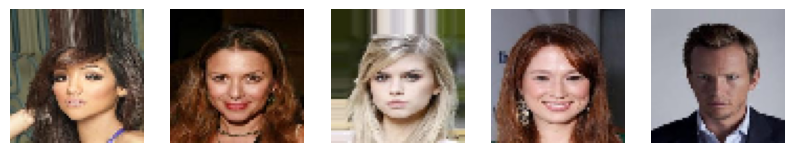

In [6]:
# ---- Display sample images ----
images, _ = next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.show()

In [7]:
# ---- Build model function for hyperparameter tuning ----
def build_model(hp):
    f1 = hp.Choice("filters_1", [32, 64])
    f2 = hp.Choice("filters_2", [16, 32])
    lr = hp.Choice("learning_rate", [0.001, 0.0005])

    input_img = Input(shape=(64,64,3))

    x = Conv2D(f1,(3,3),activation="relu",padding="same")(input_img)
    x = MaxPooling2D((2,2),padding="same")(x)
    x = Conv2D(f2,(3,3),activation="relu",padding="same")(x)
    encoder = MaxPooling2D((2,2),padding="same")(x)

    x = Conv2D(f2,(3,3),activation="relu",padding="same")(encoder)
    x = UpSampling2D((2,2))(x)
    x = Conv2D(f1,(3,3),activation="relu",padding="same")(x)
    x = UpSampling2D((2,2))(x)
    decoded = Conv2D(3,(3,3),activation="sigmoid",padding="same")(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer=Adam(learning_rate=lr), loss="binary_crossentropy")
    return autoencoder

In [8]:
# ---- Hyperparameter Search ----
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=3,
    executions_per_trial=1,
    directory="tuner_dir",
    project_name="autoencoder_tuning",
    overwrite=True
)

tuner.search(
    train_generator,
    epochs=3,
    validation_data=validation_generator
)

best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:", best_hp.values)

Trial 3 Complete [00h 05m 33s]
val_loss: 0.496521532535553

Best val_loss So Far: 0.491446316242218
Total elapsed time: 00h 10m 34s
Best hyperparameters: {'filters_1': 32, 'filters_2': 16, 'learning_rate': 0.001}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [9]:
# ---- Train the best model ----
history_tuned = best_model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 55s 422ms/step - loss: 0.5053 - val_loss: 0.4913
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 414ms/step - loss: 0.4905 - val_loss: 0.4903
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 403ms/step - loss: 0.4898 - val_loss: 0.4895
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 49s 390ms/step - loss: 0.4891 - val_loss: 0.4889
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 398ms/step - loss: 0.4886 - val_loss: 0.4884
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 49s 395ms/step - loss: 0.4882 - val_loss: 0.4882
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 387ms/step - loss: 0.4876 - val_loss: 0.4875
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 397ms/step - loss: 0.4873 - val_loss: 0.4873
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 397ms/step - loss: 0.4868 - val_loss: 0.4867
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 402ms/step - loss: 0.4866 - val_loss: 0.4867


### Training and Validation Loss

Let's visualize the training and validation loss to assess the model's performance and detect any overfitting or underfitting.

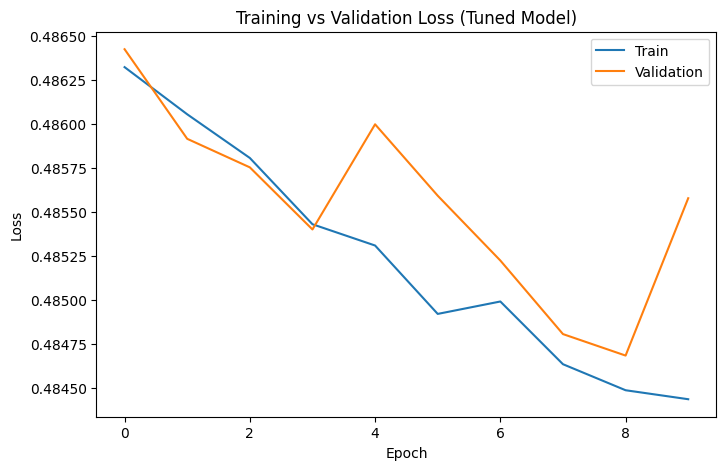

In [14]:
plt.figure(figsize=(8,5))
plt.plot(history_tuned.history['loss'])
plt.plot(history_tuned.history['val_loss'])
plt.title('Training vs Validation Loss (Tuned Model)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [11]:
# ---- Evaluate Model ----
loss = best_model.evaluate(validation_generator)
print("Final Validation Loss:", loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.4856
Final Validation Loss: 0.4855765998363495


In [ ]:
# ---- Reconstruct Images ----
images, _ = next(validation_generator)
reconstructed_images = best_model.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step


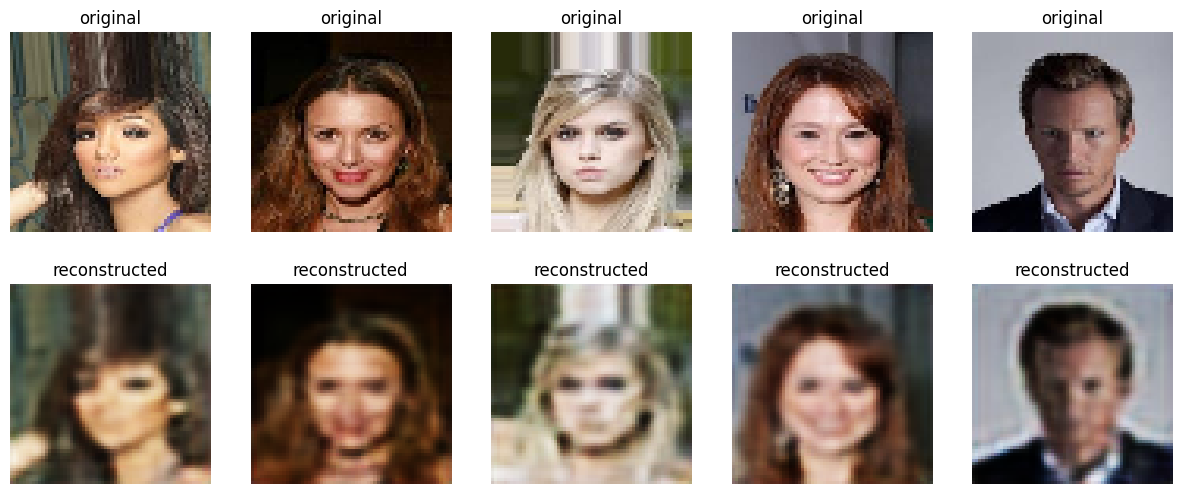

In [13]:
# ---- Display result ----
# Ensure reconstructed_images is defined for display
reconstructed_images = best_model.predict(images)

n = 5
plt.figure(figsize=(15,6))
for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(images[i])
    plt.title("original")
    plt.axis("off")
    plt.subplot(2,n,i+1+n)
    plt.imshow(reconstructed_images[i])
    plt.title("reconstructed")
    plt.axis("off")
plt.show()